In [54]:
import pandas as pd 
import optuna
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error, roc_auc_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBClassifier
import lightgbm as lgb
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)


In [2]:
df = pd.read_csv('../data/data_for_model.csv')

In [3]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,Age_Group,Income_Group
0,1,0.766127,45,2,0.802982,9120.0,13,0,4,0,2.0,41-50,średni - wyższy
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,31-40,niski dochód
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,31-40,średni - niższy
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,<30,średni - niższy
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,41-50,wysoki dochód


In [ ]:

df.isna().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
Age_Group                               0
Income_Group                            0
dtype: int64

In [ ]:
# usuwamy wartości brakujące 
df = df.dropna()

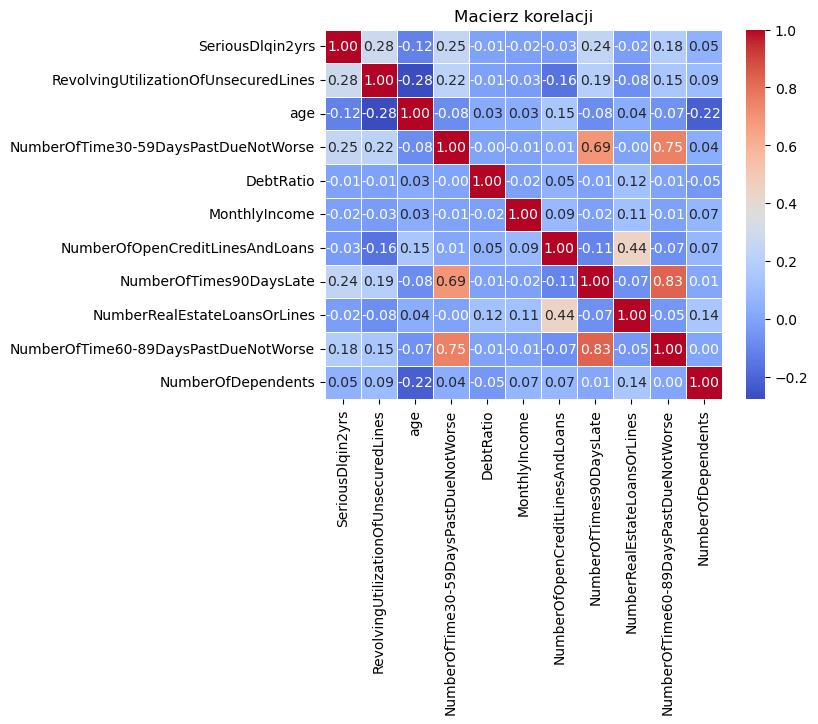

In [14]:
# tworzymy zmienną na dane numeryczne i korelacje 
num_corr = df.select_dtypes(include=['float64', 'int64'])
corr = num_corr.corr()

#tworzymy wykres i sprawdzamy korelacje pomiędzy zmiennymi
sns.heatmap(
    corr, 
    annot=True,
    cmap='coolwarm',
    fmt=".2f", 
    linewidths=0.5
    )
plt.title('Macierz korelacji')
plt.show()

In [15]:
# sprawdzamy zbalansowanie klas 

df['SeriousDlqin2yrs'].value_counts()

SeriousDlqin2yrs
0    137678
1      9939
Name: count, dtype: int64

In [16]:
# dzielimy dane zbiór testowy i zbiór treningowy 

target = 'SeriousDlqin2yrs'

X = df.drop(columns = 'SeriousDlqin2yrs')
y = df[target]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42)

In [18]:
# dzielimy dane na numeryczne i kategoryczne 

num_cols = X.select_dtypes(include=['float64', 'int64']).columns
cat_cols = X.select_dtypes(include=['object', 'string']).columns

In [ ]:
# tworzymy pipeline do przetwarzania danych numerycznych 

num_processor = SkPipeline([
    ('imputer', SimpleImputer(strategy= 'median')),
    ('scaler', StandardScaler())
])

In [ ]:
# tworzymy pipeline do przetwarzania danych numerycznych 

cat_processor = SkPipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder())
])

In [ ]:
# łączymy całość za pomocą columntransoformer

preproccesing = ColumnTransformer([
    ('num_processing', num_processor, num_cols),
    ('cat_processing', cat_processor, cat_cols)
])

Wybrałem ROC-AUC, ponieważ najlepiej ocenia zdolność modelu do odróżniania dłużników od rzetelnych klientów przy dużej dysproporcji klas, niezależnie od przyjętego progu decyzji.

In [ ]:
# sprawdzamy Wyniki 3 wybranych modeli klasyfikacyjnych 

results = []

models = [
    ('randomforest', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgbclass', XGBClassifier( eval_metric='logloss', random_state = 42)),
    ('lightgbm', lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05, num_leaves=31, random_state=42))
]



for name, model in models :
    pipe  = ImbPipeline([
    ('procesowanie', preproccesing),
    ('smote', BorderlineSMOTE(random_state=42)),
    ('model', model)
])
    
    pipe.fit(X_train,y_train)
    
    score = roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])
    results.append((name,score))

print(pd.DataFrame(results, columns= ['Model', 'Auc']))


c:\Users\Thinkpad\miniconda3\envs\ds\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:20:21] WARNING: C:\Users\task_177465309458303\croot\xgboost-split_1774653200626\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 110180, number of negative: 110180
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013872 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4838
[LightGBM] [Info] Number of data points in the train set: 220360, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
          Model       Auc
0  randomforest  0.835949
1      xgbclass  0.849855
2      lightgbm  0.858971


c:\Users\Thinkpad\miniconda3\envs\ds\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:

light_model = lgb.LGBMClassifier(random_state=42,verbose=-1)
pipeline = ImbPipeline([
    ('procesowanie', preproccesing),
    ('smote', BorderlineSMOTE(random_state=42)),
    ('model', light_model )
])

In [ ]:
# poprawiamy hiperparmatry za pomocą Optuny 

def objective(trial):
    
    param = {
        'smote__sampling_strategy': trial.suggest_float('smote__sampling_strategy', 0.5, 1.0),
        'model__max_depth': trial.suggest_int('model__max_depth', 3, 15),
        'model__learning_rate': trial.suggest_float('model__learning_rate', 0.01, 0.3, log=True),
        'model__n_estimators': trial.suggest_int('model__n_estimators', 100, 500),
        'model__min_child_samples': trial.suggest_int('model__min_child_samples', 20, 500),
        'model__num_leaves': trial.suggest_int('model__num_leaves', 20, 150),
        'model__n_jobs': -1
    }

    
    pipeline.set_params(**param)

     
    
    score = cross_val_score(pipeline, X_train, y_train, cv=3, scoring='roc_auc').mean()
    
    return score


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50) 

print("Najlepszy wynik Roc auc:", study.best_value)
print("Najlepsze parametry:", study.best_params)

Najlepszy wynik Roc auc: 0.85875941738252
Najlepsze parametry: {'smote__sampling_strategy': 0.5001080158394713, 'model__max_depth': 5, 'model__learning_rate': 0.024101521769518682, 'model__n_estimators': 149, 'model__min_child_samples': 344, 'model__num_leaves': 62}


In [ ]:
# ustawiamy najlepsze parametry i sprawdzamy wyniki

pipeline.set_params(**study.best_params)
pipeline.fit(X_train, y_train)

y_pred_standard = pipeline.predict(X_test)


print("Raport klasyfikacji :")
print(classification_report(y_test, y_pred_standard))

print("Macierz pomyłek:")
print(confusion_matrix(y_test, y_pred_standard))

Raport klasyfikacji :
              precision    recall  f1-score   support

           0       0.97      0.92      0.94     27498
           1       0.34      0.57      0.43      2026

    accuracy                           0.89     29524
   macro avg       0.65      0.74      0.68     29524
weighted avg       0.92      0.89      0.91     29524

Macierz pomyłek:
[[25267  2231]
 [  876  1150]]


Udało  się zoptymalizować model tak, żeby lepiej radził sobie z wykrywaniem dłużników. Oto co wyszło w testach:

Skuteczność (Recall): 57% – Wyłapał ponad połowę osób, które nie oddałyby kredytu. 

Precyzja (Precision): 34% – Tutaj widać, że model jest dość "podejrzliwy". Na każdą trafną odmowę przypadają mniej więcej dwie pomyłki, gdzie model odrzucił uczciwego klienta.

Balans (F1-Score): 0.43 – To nasz główny wskaźnik pokazujący kompromis między wykrywaniem długów a nieodrzucaniem wszystkich jak leci.

Co to oznacza w praktyce (Macierz Pomyłek):

Uratowane pieniądze (TP): Zablokowałem kredyt dla 1150 dłużników.

Błędy krytyczne (FN): Niestety 876 dłużników prześlizgnęło się przez model – to nad nimi musimy jeszcze popracować.

Stracone okazje (FP): Przez zbytnią ostrożność modelu, aż 2231 dobrych klientów nie dostało kredytu.

Krótki wniosek:
Zastosowanie BorderlineSMOTE bardzo pomogło – model przestał ignorować dłużników i stał się bardziej czujny. Ogólna celność to aż 89%, ale w bankowości ważniejsze jest dla nas to, że wyłapujemy te 57% dłużników, nawet jeśli ceną jest odrzucenie części dobrych wniosków.

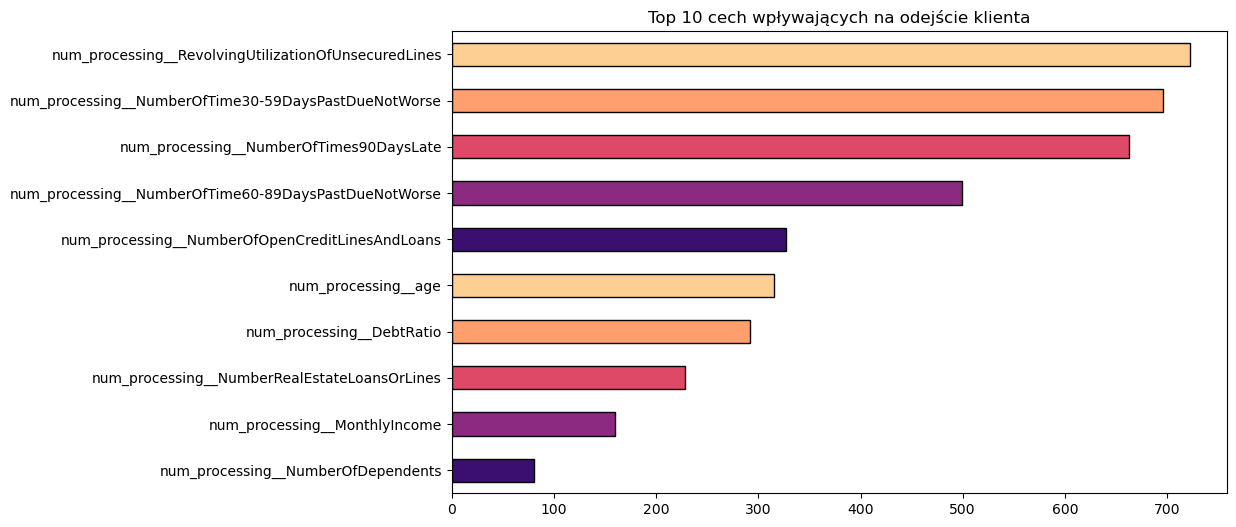

In [ ]:

importances = pipeline.named_steps['model'].feature_importances_
features = pipeline.named_steps['procesowanie'].get_feature_names_out()

# tworzymy  wykres  przedtawiający 10 najważniejszych cech dla modelu
plt.figure(figsize=(10, 6))
pd.Series(importances, index=features).sort_values().tail(10).plot(
    kind='barh',
    color=plt.cm.magma([0.2, 0.4, 0.6, 0.8, 0.9]),
    edgecolor = 'black')
plt.title("Top 10 cech wpływających na odejście klienta")

plt.show()

Co nam mówi model?

Patrząc na powyższy wykres Feature Importance, mogę wyciągnąć kilka ciekawych wniosków o tym, jak model ocenia ryzyko kredytowe:

Najważniejsza cecha: 'RevolvingUtilizationOfUnsecuredLines'. To ma ogromny sens biznesowy – jeśli ktoś „czyści” swoje karty kredytowe do zera, to znak, że może mieć problem z płynnością finansową.

Historia opóźnień: Cechy takie jak 'NumberOfTime30-59Days' czy 'NumberOfTimes90DaysLate' są bardzo wysoko. Model nauczył się, że jeśli ktoś spóźniał się w przeszłości, to prawdopodobnie zrobi to znowu. To najważniejszy sygnał ostrzegawczy dla banku.

Wiek i Dochód: 'age' i 'MonthlyIncome' też są istotne, ale mniej niż historia spłat. 

Podsumowanie :
Udało się zbudować model, który nie tylko ma dobre statystyki (AUC), ale też podejmuje decyzje w oparciu o logiczne przesłanki ekonomiczne. Dzięki zastosowaniu LightGBM, model jest w stanie wyłapać nieliniowe zależności (np. że DebtRatio jest groźne dopiero powyżej pewnego poziomu), których zwykła regresja mogłaby nie zauważyć.